In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt


In [36]:
# we create a list of the files we downloaded from common voice apart from voice
files = ['validated.tsv','invalidated.tsv','other.tsv','reported.tsv']

# we create an empty dictionary where we will store the contents of each file separately 
dataframes = {}

# run through all the files
for file in files:
    # we read each file in to a dataframe
    df = pd.read_table(file)
    
    # we then add the dataframe to the dictionary with the file name as the key
    dataframes[file] = df

# Exploring the validated data


The validated data is the .tsv file that came together with the the audio clips, invalidated.tsv, others.tsv and reported.tsv when I downloaded the swahili data from common voice as shown on the screen shot below ![swahili](sw).

### Validated data 
contains the swahili sentences that are validated by volunteers (contributors) on common voice platform. 

We need to answer some questions about the data before we can use it for training. Below is a list of the preliminary questions we aim to answer about this validated data ahead of :
1. How many sentences have been validated?
2. How many have the more than three up votes?
3. How many are from a female? 
4. what is the medium/mean age of the people who contributed this dataset?
5. Do we have missing data? 
6. How shall we handle it and why?
7. Do we have a client who contributed more than one sentences?
8. Which are the topics of the validated sentences?
9. Are the samples balanced? Are there more samples from some speakers than others?
10. The diversity of the data in terms of accents, age, gender and dialect. How is it in this dataset?

In [17]:
# we will store the validated.tsv file in a variable called validated_data
validated_data = dataframes['validated.tsv']
#we just read the first five rows
validated_data.head()

,client_id,path,sentence,up_votes,down_votes,age,gender,accents,locale,segment
0,109ce2e2aa73581337898e38918a6fe1db807c5b71dcb1...,common_voice_sw_36300004.mp3,idadi ya watoto yatima inaongezeka kwa kasi sana,4,0,twenties,male,NaN,sw,NaN
1,120414bea137eab7d14719d6d81501ff21546ca7719b73...,common_voice_sw_35895985.mp3,Aidha neno nyambo linamaanisha mtu au kitu au ...,5,0,0,unknown,NaN,sw,NaN
2,172282c37f318c5686a85f5a56c444323feac2c8f4ff80...,common_voice_sw_35774990.mp3,Maskini kusema hawachoki kuchonga,14,0,0,unknown,NaN,sw,NaN
3,2b866fb04e8161a3cb193ab28065fcff1bed0bbf54e41b...,common_voice_sw_35774955.mp3,Maneno mema hutowa nyoka pangoni,17,2,0,unknown,NaN,sw,NaN
4,2b98fb1815f98abbe0b0056954124c6cab373203682114...,common_voice_sw_35085937.mp3,Miaka mitatu ijayo ntakuwa nimemaliza,2,1,0,unknown,NaN,sw,NaN


# how is the data distributed:
so we can answer the question of: 
1. how many sentences are validated?
2. How many missing data exist?

In [4]:
print(validated_data.info())
print("-----------------------------------------------------------")
print(validated_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7956 entries, 0 to 7955
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   client_id   7956 non-null   object 
 1   path        7956 non-null   object 
 2   sentence    7956 non-null   object 
 3   up_votes    7956 non-null   int64  
 4   down_votes  7956 non-null   int64  
 5   age         2824 non-null   object 
 6   gender      2817 non-null   object 
 7   accents     0 non-null      float64
 8   locale      7956 non-null   object 
 9   segment     0 non-null      float64
dtypes: float64(2), int64(2), object(6)
memory usage: 621.7+ KB
None
-----------------------------------------------------------
          up_votes   down_votes  accents  segment
count  7956.000000  7956.000000      0.0      0.0
mean      3.544997     0.882479      NaN      NaN
std       3.098202     1.192851      NaN      NaN
min       2.000000     0.000000      NaN      NaN
25%       2.000000    

# observations:
1. we have missing values on age and  gender columns
2. we dont have entries in accents and segments 
3. we have 7956 validated sentences
4. We do not need locale column during training


### since we dont have any accents or segments in the dataframe, 
we drop those columns

In [23]:
validated_data.drop(columns=['accents','segment'], inplace= True)

### what is locale?

In [27]:
# single out the locale column from the validated data
locale_content = validated_data['locale']

# Check the number of unique values in the column
if locale_content.nunique() == 1:
    print("All elements in the locale column are the same.")
else:
    print("Elements in the locale column are not all the same.")

All elements in the locale column are the same.


### since all elements in the locale column are the same, 
we can also drop it

In [28]:
# remove the locale column from the  original dataframe
del validated_data['locale']

### we removed 3 columns (accent and segment -> because they contained null values), (locale because it only contained 'sw' in all it rows). we now have 7 columns from 10.

In [29]:
#confirming how many columns are now in the validated data
validated_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7956 entries, 0 to 7955
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   client_id   7956 non-null   object
 1   path        7956 non-null   object
 2   sentence    7956 non-null   object
 3   up_votes    7956 non-null   int64 
 4   down_votes  7956 non-null   int64 
 5   age         7956 non-null   object
 6   gender      7956 non-null   object
dtypes: int64(2), object(5)
memory usage: 435.2+ KB


# what is the distribution of female and male on the data and the ages of the entries

In [5]:
imputing_missing_values = validated_data.fillna(value= {'gender':'unknown', 'age':0}, inplace = True)

 #### we just replaced NaN in gender column to unknown, and in age column to 0

Text(0.5, 1.0, 'Gender Distribution on the validated data')

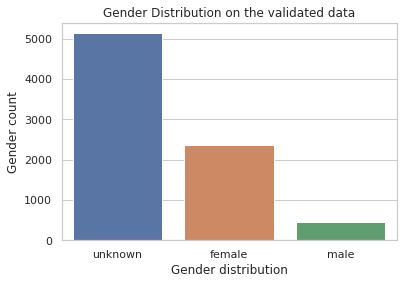

In [6]:
#count the occurrences of gender in the validated data
gender_counts = validated_data['gender'].value_counts()

#plot the count against the distribution
by_gender = sns.barplot(x = gender_counts.index, y = gender_counts.values, data = validated_data)

#add labels to the graph
plt.xlabel('Gender distribution')
plt.ylabel('Gender count')
plt.title('Gender Distribution on the validated data')

# Observations:
1. We have way more females than male
2. We have more than 5000 entries that we dont know which gender they came from

Text(0.5, 1.0, 'age Distribution on the validated data')

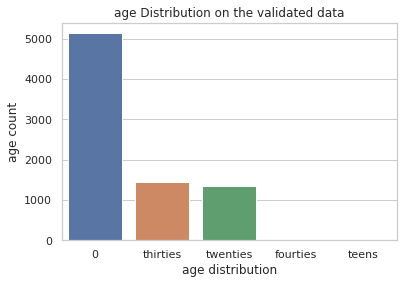

In [7]:
#we do the same for age right?
age_count = validated_data['age'].value_counts()

#plot age 
by_age = sns.barplot(x = age_count.index, y = age_count.values)

#labels to the graph
plt.xlabel('age distribution')
plt.ylabel('age count')
plt.title('age Distribution on the validated data')

# Observations:
1. we have a huge number of sentences that we don't know the ages of their contributors.
2. we slightly more thirty somethings than twenties.

# How are the upvotes distributed?

In [8]:
# slice rows with more than two upvotes
more_than2_upvotes = validated_data[validated_data['up_votes'] > 2]

#how many are they?
print("Entries with more than 2 up votes are ," + str(len(more_than2_upvotes)))

more_than2_downvotes = validated_data[validated_data['down_votes'] > 2]

print("Entries with more than 2 down votes are ," + str(len(more_than2_downvotes)))

Entries with more than 2 up votes are ,3390
Entries with more than 2 down votes are ,515


# What is the distribution of speakers like?

1. do we have multiple speakers?


In [98]:
#create a variable to store the unique IDs 
unique_ids = validated_data['client_id'].nunique()

#we then print out a comparison of those IDs versus the total number of IDs
print("We have ", unique_ids, "unique IDs. Out of a total of " + str(len(validated_data['client_id'])) + " IDs")

We have  216 unique IDs. Out of a total of 7956 IDs


This is the grouped data
                                                      up_votes  down_votes
client_id                                                               
00a577a6e13d02ce2dc80c2e94bd28c437f91f8b1a43fa2...  4.130435    1.913043
01e4797f3d71b35d2f0e5cdacd4e1bd83922da7a8c375c3...  3.285714    0.142857
040e1a31dbf6e0e12cdf36fef8128c3d7ddcddfdfd930bb...  3.500000    0.625000
044fd6e346e984fd6e1b3f0e2bfdf9f906b05de6e2f4dc8...  3.428571    0.190476
060e9e622a198ddab7ca519873929bf9c0dfeec5480f54d...  2.123810    0.561905

 And this is top 10 in order of up_votes 
                                                      up_votes  down_votes
client_id                                                                
2b866fb04e8161a3cb193ab28065fcff1bed0bbf54e41b1...  17.000000    2.000000
172282c37f318c5686a85f5a56c444323feac2c8f4ff80c...  14.000000    0.000000
944e043bb81c7577dfc16f0e484fdb0eaebab741787162b...  10.000000    1.000000
c4bf54f6aa3d2cb0128c105bad197e3c7cd946cb4088745.

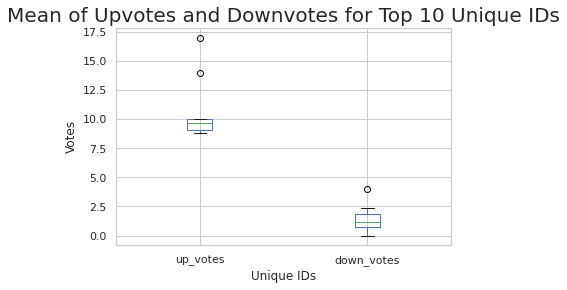

In [95]:
# group the validated data by unique id and get the mean of upvotes and downvotes
grouped_data = validated_data.groupby(['client_id'])[['up_votes','down_votes']].mean()
print("This is the grouped data\n ", grouped_data.head())

# get the top 10 unique ids
top_10_ids = grouped_data.nlargest(10,'up_votes')
print("\n And this is the top 10 in order of up_votes \n" , top_10_ids)

# create the bar plots
top_10_ids.plot(kind='box', stacked=True)

# add labels and title
plt.xlabel('Unique IDs')
plt.ylabel('Votes')
plt.title('Mean of Upvotes and Downvotes for Top 10 Unique IDs', fontsize = 20)

# show the plot
plt.show()

# Observations from box plot:

Spread: the boxes are relatively short, meaning that the up and down votes are not that much spread. 

Median: the middle value for upvote is close to 10. while the middle value in down vote is below 2.5


Outliers: There are the up and downvotes that fall outside of the range of most of the data (outliers).

Skewness:looks like the boxes are not skewed to the left nor to the right as the boxes fall on the line

Comparison: the up and down votes are similiarly distributed since they have relatively same sizes but have different mean.

# Which are the most frequent words? The distribution of words.

#### we choose visualization - word cloud



In [9]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


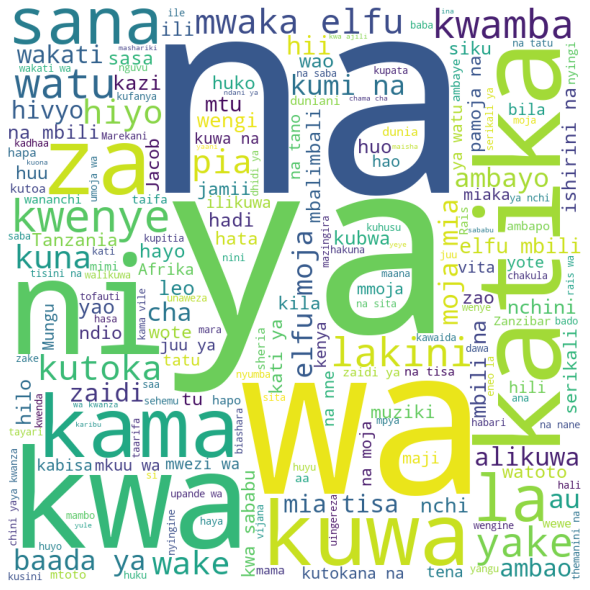

In [16]:
from wordcloud import WordCloud

# create a list of sentences from the column 'sentences'
text = validated_data['sentence'].tolist()

# Join all the sentences in the list into one string
text = " ".join(text)

# Create a wordcloud object
wordcloud = WordCloud(width = 800, height = 800, 
                background_color ='white', 
                min_font_size = 10).generate(text)

# Plot the wordcloud
plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 
  
plt.show() 


# Exploring the audio files:
Here are some of the questions we shall ask in order to understand the audio samples (from common voice) that we shall use to show a computer to hear swahili audio.

1. What are the distribution of the audio files' duration? Are there any outliers?
2. Are the samples recorded in different environments?
3. Are all swahili samples?
4. Are there any samples with low or high volume?
5. Are there any errors in the transcription?
6. Are there any samples with multiple speakers?


In [99]:
pip install librosa


     |████████████████████████████████| 214 kB 162 kB/s eta 0:00:01
     |████████████████████████████████| 377 kB 30 kB/s eta 0:00:012
     |████████████████████████████████| 3.1 MB 20 kB/s eta 0:00:01
     |████████████████████████████████| 56 kB 31 kB/s eta 0:00:01
  Created wheel for audioread: filename=audioread-3.0.0-py3-none-any.whl size=23706 sha256=5d03fcc59cb8f94e43e184ebf6a3311507d2b7ac337468badc6198559bf6278e
  Stored in directory: /home/antonym/.cache/pip/wheels/e4/76/a4/cfb55573167a1f5bde7d7a348e95e509c64b2c3e8f921932c3
Successfully built audioread
Note: you may need to restart the kernel to use updated packages.


In [41]:
#used for loading audio files
import librosa

#glob is used to get a list of paths
import glob

import os

In [ ]:
file_paths = [os.path.join(audioclips_directory, file) for file in os.listdir(audioclips_directory)]

In [43]:
#the directory with the swahili clips
audioclips_directory ="~/clips"

#initialize empty lists where we shall populate the sample rates and the audio samples
audio_samples = []
sample_rates = []

#get a list of file paths
#file_paths = glob.glob(audioclips_directory)
file_paths = [os.path.join(audioclips_directory, file) for file in os.listdir(audioclips_directory)]


#loop through all the audio samples as you append them into the empty list accordingly
for file_path in file_paths:
    try:
        audio, sr = librosa.load(file_path)
        audio_samples.append(audio)
        sample_rates.append(sr)
    except Exception as e:
        print(f"Error occured while processing {file_path} : {e}")

FileNotFoundError: [Errno 2] No such file or directory: '~/clips'

In [ ]:
pip install torchaudio

     |████████████████████████████████| 4.2 MB 228 kB/s eta 0:00:01
     |███████████████                 | 413.8 MB 915 kB/s eta 0:08:38    |███                             | 84.6 MB 739 kB/s eta 0:18:06     |███▏                            | 86.7 MB 178 kB/s eta 1:14:41     |███▉                            | 106.8 MB 332 kB/s eta 0:39:08     |████▌                           | 123.7 MB 577 kB/s eta 0:22:03     |██████▌                         | 178.9 MB 506 kB/s eta 0:23:18     |███████▌                        | 207.6 MB 1.0 MB/s eta 0:11:14     |██████████▍                     | 288.8 MB 337 kB/s eta 0:29:36     |████████████▍                   | 343.0 MB 654 kB/s eta 0:13:52     |████████████▌                   | 345.8 MB 399 kB/s eta 0:22:35     |█████████████                   | 359.4 MB 428 kB/s eta 0:20:33     |█████████████▋                  | 378.7 MB 416 kB/s eta 0:20:21     |█████████████▊                  | 380.7 MB 525 kB/s eta 0:16:04     |██████████████                  

In [ ]:
len(audio_samples)

In [15]:
# what is the duration of each clip?


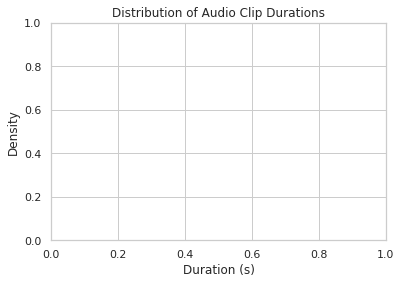

In [16]:
# calculate the duration of each clip
clips_duration = [librosa.get_duration(clip) for clip in audio_samples]

# plot the density of the durations
sns.kdeplot(clips_duration, shade=True)

# add labels and title
plt.xlabel('Duration (s)')
plt.ylabel('Density')
plt.title('Distribution of Audio Clip Durations')

# show the plot
plt.show()

# exploring invalidated data

In [ ]:
invalidated_data = dataframes['invalidated.tsv']
invalidated_data.head()

In [ ]:
invalidated_data.info()

# Exploring other files

In [40]:
# this is one of the file contained in the zip folder I downloaded from common voice
other_file = dataframes['other.tsv']
other_file.head()

,client_id,path,sentence,up_votes,down_votes,age,gender,accents,locale,segment
0,aecdf573e8bd61d1a795e1eb620b6332a2ae5d4d501a2e...,common_voice_sw_35085410.mp3,na hii ni moja ya njia ya kushughulikia masual...,1,1,NaN,NaN,NaN,sw,NaN
1,dbfe4f658430812c2ff2076e174cc723736262c48f79b1...,common_voice_sw_35085509.mp3,za kuongoza tu kwa mihula miwili,1,1,NaN,NaN,NaN,sw,NaN
2,7f8a71e91f9083f87fc16491257a0ddbaf2003bfafc5dd...,common_voice_sw_35085546.mp3,Mama ni mkali,1,1,NaN,NaN,NaN,sw,NaN
3,64c154b91aa964192ef24b276d01af045ed7d0556af9d1...,common_voice_sw_35085637.mp3,elfu tisa mia saba hamsini na tano nukta sita ...,1,1,NaN,NaN,NaN,sw,NaN
4,aecdf573e8bd61d1a795e1eb620b6332a2ae5d4d501a2e...,common_voice_sw_35085682.mp3,haki za binadamu hazikuzingatiwa kabisa katika...,1,1,NaN,NaN,NaN,sw,NaN


In [39]:
other_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53029 entries, 0 to 53028
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   client_id   53029 non-null  object 
 1   path        53029 non-null  object 
 2   sentence    53029 non-null  object 
 3   up_votes    53029 non-null  int64  
 4   down_votes  53029 non-null  int64  
 5   age         19422 non-null  object 
 6   gender      19280 non-null  object 
 7   accents     0 non-null      float64
 8   locale      53029 non-null  object 
 9   segment     0 non-null      float64
dtypes: float64(2), int64(2), object(6)
memory usage: 4.0+ MB
